This notebook focuses on trying to find a way to segment cells within organoids properly.
The end goal is to segment cells and extract morphology features from CellProfiler.
These masks must be imported into CellProfiler to extract features.

## import libraries 

In [1]:
import argparse
import os
import pathlib
import sys
from typing import Union

import cucim
import cupy
import cupyx
import cupyx.scipy.ndimage
import matplotlib.pyplot as plt

# Import dependencies
import numpy as np
import scipy
import skimage
import tifffile
from image_analysis_2D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_2D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from image_analysis_2D.file_utils.profiling_utils import (
    start_resource_profiling,
    stop_resource_profiling,
)
from image_analysis_2D.segmentation_utils.segmentation_processing import (
    fill_holes_in_mask,
    remove_small_objects_preserve_labels,
)
from skimage import io, segmentation

root_dir, in_notebook = init_notebook()
image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

/home/lippincm/4TB_A/NF1_2D_organoid_profiling_pipeline/.venv/lib/python3.13/site-packages/cupy/_environment.py:677: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda12x, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [2]:
start_time, start_mem = start_resource_profiling()

## parse args and set paths

If a notebook run the hardcoded paths.
However, if this is run as a script, the paths are set by the parsed arguments.

In [3]:
if not in_notebook:
    args_dict = parse_args()
    patient = args_dict["patient"]
    well_fov = args_dict["well_fov"]
    clip_limit = args_dict["clip_limit"]
    twoD_method = args_dict["twoD_method"]
    check_for_missing_args(
        patient=patient,
        well_fov=well_fov,
        clip_limit=clip_limit,
        twoD_method=twoD_method,
    )
else:
    print("Running in a notebook")
    patient = "NF0014_T1"
    well_fov = "C4-2"
    clip_limit = 0.04
    twoD_method = "zmax"


if twoD_method == "zmax":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0a.zmax_proj/{well_fov}"
    ).resolve(strict=True)
elif twoD_method == "middle":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0b.middle_slice/{well_fov}"
    ).resolve(strict=True)
elif twoD_method == "middle_n":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0c.middle_n_slice_max_proj/{well_fov}"
    ).resolve(strict=True)
else:
    raise ValueError(f"Unknown twoD_method: {twoD_method}")


organoid_mask_path = input_dir / f"{well_fov}_organoid_mask.tiff"

Running in a notebook


## Set up images, paths and functions

In [4]:
image_extensions = {".tif", ".tiff"}
files = sorted(input_dir.glob("*"))
files = [str(x) for x in files if x.suffix in image_extensions]
# get the nuclei image
for f in files:
    if "555" in f:
        cell = io.imread(f)

/tmp/ipykernel_1118437/301641509.py:21: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  tmp_mask = skimage.morphology.remove_small_holes(tmp_mask, area_threshold=10_000)
/tmp/ipykernel_1118437/301641509.py:21: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  tmp_mask = skimage.morphology.remove_small_holes(tmp

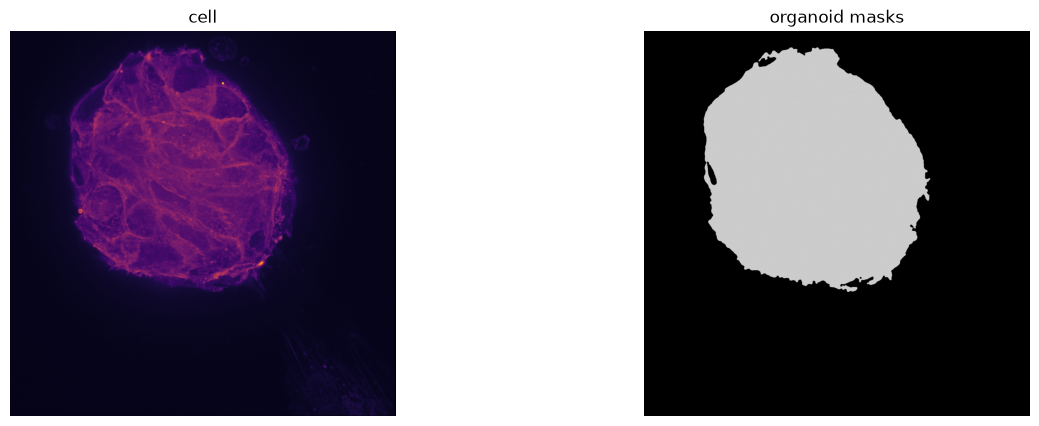

In [5]:
elevation_map_threshold_signal = skimage.filters.gaussian(cell, sigma=3)
threshold = skimage.filters.threshold_otsu(elevation_map_threshold_signal)
elevation_map_threshold_signal[elevation_map_threshold_signal < threshold] = 0
elevation_map_threshold_signal[elevation_map_threshold_signal > 0] = 1
elevation_map_threshold_signal = skimage.morphology.dilation(
    elevation_map_threshold_signal,
    skimage.morphology.disk(1),
)

organoid_mask = fill_holes_in_mask(
    elevation_map_threshold_signal, compartment="organoid"
)


# clean each object independently and write to a fresh label image
cleaned_labels = np.zeros_like(organoid_mask, dtype=organoid_mask.dtype)
for organoid_mask_label in np.unique(organoid_mask):
    if organoid_mask_label == 0:
        continue
    tmp_mask = organoid_mask == organoid_mask_label
    tmp_mask = skimage.morphology.remove_small_holes(tmp_mask, area_threshold=10_000)
    # closing
    tmp_mask = skimage.morphology.closing(
        tmp_mask, footprint=skimage.morphology.disk(3)
    )
    cleaned_labels[tmp_mask] = organoid_mask_label
organoid_mask = cleaned_labels


organoid_mask = remove_small_objects_preserve_labels(organoid_mask, min_size=500)
if in_notebook:
    plt.figure(figsize=(15, 5))
    plt.subplot(121)
    plt.imshow(cell, cmap="inferno")
    plt.axis("off")
    plt.title("cell")
    plt.subplot(122)
    plt.imshow(organoid_mask, cmap="nipy_spectral")
    plt.axis("off")
    plt.title("organoid masks")
    plt.show()
# save the labels
tifffile.imwrite(organoid_mask_path, organoid_mask.astype(np.uint16))

In [6]:
stop_resource_profiling(
    start_time=start_time,
    start_mem=start_mem,
    feature_type="Segmentation",
    well_fov=well_fov,
    patient_id=patient,
    channel="NoChannel",
    compartment="organoid",
    CPU_GPU="GPU",
    output_file_dir=pathlib.Path(
        f"{input_dir.parent}/run_stats/{well_fov}_organoid_segmentation.parquet"
    ),
)


        Memory and time profiling for the run:
        Patient ID: NF0014_T1
        Well and FOV: C4-2
        Feature type: Segmentation
        CPU/GPU: GPU
        Peak memory (tracemalloc): 185.48 MB
        Current memory (tracemalloc): 70.65 MB
        RSS at end: 684.04 MB
        Time elapsed:
        --- 1.98 seconds ---
        --- 0.03 minutes ---
        --- 0.00 hours ---
    


True